<a href="https://colab.research.google.com/github/WVF-1/Urban-Tree-Modeling/blob/main/Case_Studies_Mapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 — Growing Better Cities
## Part 3 of 3: Case Studies & Priority Mapping

**Building Data Together Data Science Newsletter — Series Finale**

Notebook 1 built the model. Notebook 2 opened it up and gave planners a slider to explore "what if?" scenarios. This closing notebook turns the model's **residuals** — actual tree density minus what the land-use profile predicts — into a practical planning lens:

- Cities **under-performing** their predicted density (actual << predicted) have a land-use profile that "should" support more trees than they have — worth asking why, and a plausible target for intervention.
- Cities **over-performing** (actual >> predicted) are doing something right that isn't captured by these five features — worth studying as a positive model.

We map both, then walk through a couple of named case studies combining the residual, the SHAP explanation from Notebook 2, and a widget-style "what if" scenario.


## 0. Setup

In [1]:
!pip install -q geopandas contextily

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as cx
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
NATURAL_PALETTE = ["#2E5339", "#6B8E4E", "#A9BA9D", "#C9A66B", "#8C6239", "#4A3728"]
NATURAL_CMAP = mcolors.LinearSegmentedColormap.from_list("natural", ["#C9A66B", "#6B8E4E", "#2E5339"])
# Diverging: brown = under-performing, green = over-performing (matches Week 3's BrBG logic)
RESIDUAL_CMAP = "BrBG"


## 1. Load predictions and city boundaries

In [3]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Upload week4_predictions.csv and week3_city_boundaries.geojson (from Week 3, Notebook 1)")
    uploaded = files.upload()

predictions_df = pd.read_csv("week4_predictions.csv")

# Pull lat/long back in from the Week 3 boundary file if predictions_df doesn't have them
try:
    boundaries = gpd.read_file("week3_city_boundaries.geojson")
    centroids = boundaries.copy()
    centroids["geometry"] = centroids.geometry.centroid
    centroids["lat"] = centroids.geometry.y
    centroids["long"] = centroids.geometry.x
    predictions_df = predictions_df.merge(
        centroids[["city", "lat", "long"]], on="city", how="left"
    )
except Exception as e:
    print("Could not load Week 3 boundaries, expecting lat/long already in predictions_df:", e)

gdf = gpd.GeoDataFrame(
    predictions_df,
    geometry=gpd.points_from_xy(predictions_df["long"], predictions_df["lat"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)

gdf.head()


Upload week4_predictions.csv and week3_city_boundaries.geojson (from Week 3, Notebook 1)


Saving week3_city_boundaries.geojson to week3_city_boundaries.geojson
Saving week4_predictions.csv to week4_predictions (1).csv


/tmp/ipykernel_748/1730438243.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["geometry"] = centroids.geometry.centroid


,city,state,region,trees_per_km2,elevation_m,population_density_per_km2,pct_impervious_proxy,pct_parkland,pct_water,population,predicted_trees_per_km2,residual,lat,long,geometry
0,Albuquerque,New Mexico,West,4.886074,1587.0,1073.460579,0.428055,0.101283,0.008644,556495,316.686474,-311.800400,35.107754,-106.642365,POINT (-11871373.721 4178534.077)
1,Anaheim,California,West,604.878062,61.0,2620.057374,0.433079,0.048618,0.028259,345012,337.158439,267.719623,33.838951,-117.857388,POINT (-13119824.417 4007197.532)
2,Arlington,Texas,South,57.412532,190.0,1469.783272,0.537761,0.035914,0.044521,379577,416.450189,-359.037657,32.699871,-97.125037,POINT (-10811909.637 3855534.268)
3,Atlanta,Georgia,South,117.263977,336.0,1271.349084,0.694056,0.037766,0.007924,447841,260.640985,-143.377009,33.762811,-84.422211,POINT (-9397837.556 3996997.632)
4,Aurora (CO),Colorado,West,138.218146,1652.0,828.961278,0.303586,0.036362,0.013026,345803,299.595969,-161.377823,39.706591,-104.726881,POINT (-11658143.025 4823396.102)


## 2. Residual map: who's over/under-performing their land-use profile?

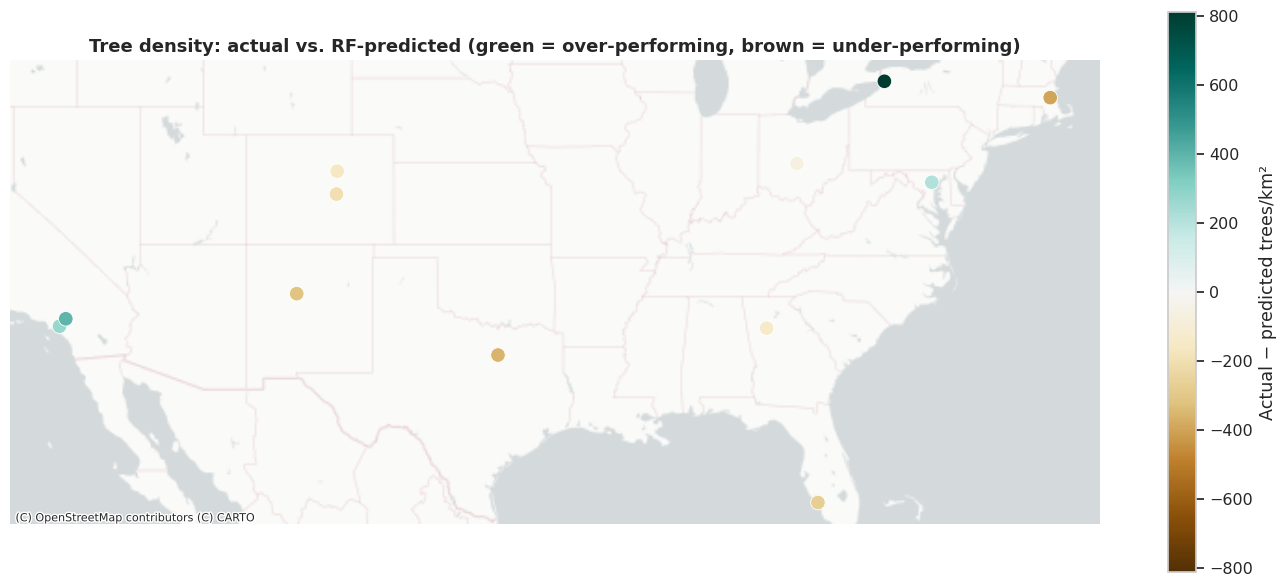

In [4]:
conus = gdf[gdf["state"] != "Hawaii"].copy() if "state" in gdf.columns else gdf.copy()

vmax = conus["residual"].abs().max()

fig, ax = plt.subplots(figsize=(14, 9))
conus.plot(
    ax=ax, column="residual", cmap=RESIDUAL_CMAP, vmin=-vmax, vmax=vmax,
    markersize=110, edgecolor="white", linewidth=0.6, legend=True,
    legend_kwds={"shrink": 0.65, "label": "Actual − predicted trees/km²"},
)
cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, zoom=4)
ax.set_axis_off()
ax.set_title(
    "Tree density: actual vs. RF-predicted (green = over-performing, brown = under-performing)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("week4_residual_map.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Ranked lists: top over- and under-performers

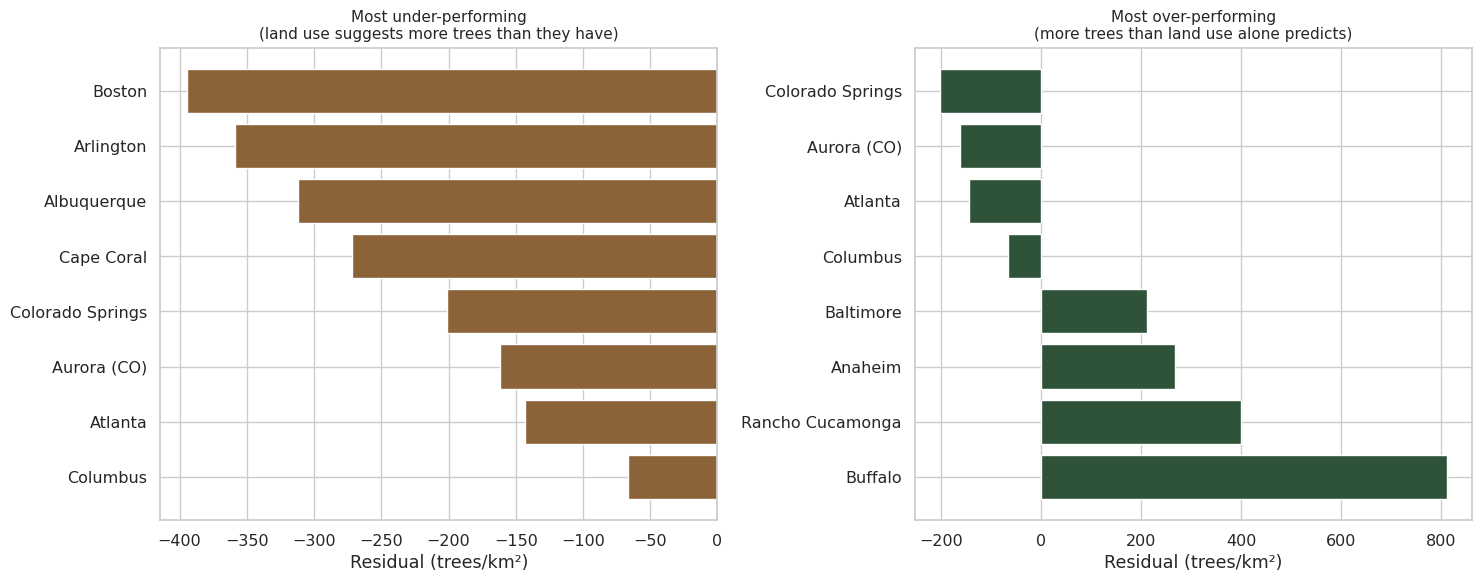

UNDER-PERFORMING (priority candidates for intervention):
            city         state  trees_per_km2  predicted_trees_per_km2    residual
          Boston Massachusetts       5.417352               399.965847 -394.548495
       Arlington         Texas      57.412532               416.450189 -359.037657
     Albuquerque    New Mexico       4.886074               316.686474 -311.800400
      Cape Coral       Florida     111.840287               383.895014 -272.054727
Colorado Springs      Colorado      50.169798               251.529420 -201.359622
     Aurora (CO)      Colorado     138.218146               299.595969 -161.377823
         Atlanta       Georgia     117.263977               260.640985 -143.377009
        Columbus          Ohio     260.986066               327.319222  -66.333156

OVER-PERFORMING (worth studying as a positive model):
            city      state  trees_per_km2  predicted_trees_per_km2    residual
         Buffalo   New York    1096.480457               284.

In [5]:
top_n = 8

under = predictions_df.nsmallest(top_n, "residual")[
    ["city", "state", "trees_per_km2", "predicted_trees_per_km2", "residual"]
]
over = predictions_df.nlargest(top_n, "residual")[
    ["city", "state", "trees_per_km2", "predicted_trees_per_km2", "residual"]
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(under["city"][::-1], under["residual"][::-1], color=NATURAL_PALETTE[4])
axes[0].set_title("Most under-performing\n(land use suggests more trees than they have)", fontsize=11)
axes[0].set_xlabel("Residual (trees/km²)")

axes[1].barh(over["city"], over["residual"], color=NATURAL_PALETTE[0])
axes[1].set_title("Most over-performing\n(more trees than land use alone predicts)", fontsize=11)
axes[1].set_xlabel("Residual (trees/km²)")

plt.tight_layout()
plt.savefig("week4_ranked_over_under.png", dpi=150, bbox_inches="tight")
plt.show()

print("UNDER-PERFORMING (priority candidates for intervention):")
print(under.to_string(index=False))
print("\nOVER-PERFORMING (worth studying as a positive model):")
print(over.to_string(index=False))


## 4. Worked case studies

Pick 2–3 cities from the ranked lists above — one strongly under-performing, one strongly over-performing, maybe one near-zero residual as a "the model nailed this one" example. For each, pull together:

- The residual and SHAP waterfall (from Notebook 2)
- The specific land-use numbers (impervious %, parkland %, density) that drove the prediction
- A concrete, narrated "what if" scenario using Notebook 2's widget — e.g., "if City X added 5 percentage points of park land, holding everything else constant, the model's prediction moves from A to B"

This cell sets up the comparison table; the narrative goes in the newsletter text around it.


In [6]:
CASE_STUDY_CITIES = under["city"].head(1).tolist() + over["city"].head(1).tolist()
# Edit CASE_STUDY_CITIES above with your chosen cities once you've reviewed the real rankings.

case_df = predictions_df[predictions_df["city"].isin(CASE_STUDY_CITIES)][
    ["city", "state", "region", "trees_per_km2", "predicted_trees_per_km2", "residual",
     "pct_impervious_proxy", "pct_parkland", "pct_water", "population_density_per_km2", "elevation_m"]
]
case_df


,city,state,region,trees_per_km2,predicted_trees_per_km2,residual,pct_impervious_proxy,pct_parkland,pct_water,population_density_per_km2,elevation_m
6,Boston,Massachusetts,Northeast,5.417352,399.965847,-394.548495,0.137253,0.079160,0.020479,2625.225373,27.0
7,Buffalo,New York,Northeast,1096.480457,284.537936,811.942521,0.153336,0.066706,0.140141,2134.993667,188.0


## 5. Regional summary: where should this newsletter's readers look first?

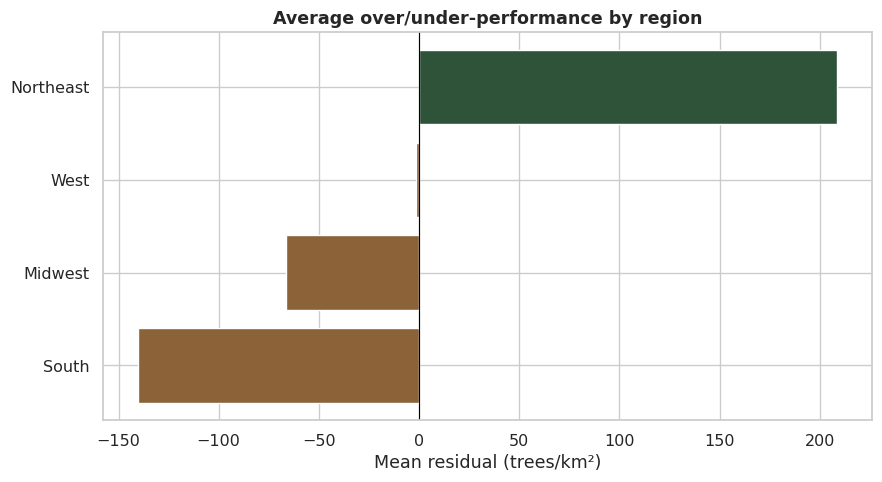

,n_cities,mean_residual,mean_actual,mean_predicted
region,,,,
South,4,-140.5,199.0,339.5
Midwest,1,-66.3,261.0,327.3
West,5,-1.6,298.2,299.8
Northeast,2,208.7,550.9,342.3


In [7]:
region_summary = predictions_df.groupby("region").agg(
    n_cities=("city", "count"),
    mean_residual=("residual", "mean"),
    mean_actual=("trees_per_km2", "mean"),
    mean_predicted=("predicted_trees_per_km2", "mean"),
).round(1).sort_values("mean_residual")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [NATURAL_PALETTE[4] if v < 0 else NATURAL_PALETTE[0] for v in region_summary["mean_residual"]]
ax.barh(region_summary.index, region_summary["mean_residual"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Mean residual (trees/km²)")
ax.set_title("Average over/under-performance by region", fontweight="bold")
plt.tight_layout()
plt.savefig("week4_region_summary.png", dpi=150, bbox_inches="tight")
plt.show()

region_summary


## Series wrap-up

Four weeks, one throughline: **from raw tree census data to an interpretable, honestly-uncertain planning tool.**

- **Week 1**: Pittsburgh street trees in isolation
- **Week 2**: All 63 cities, comparison visuals and mapping
- **Week 3**: Land-use predictors merged in — elevation, density, impervious surface, parkland, water — plus exploratory correlation and clustering work
- **Week 4**: A Random Forest predicting tree density from those predictors, evaluated honestly at n=63 (LOOCV, not a single lucky train/test split), opened up with SHAP and permutation importance, and turned into an interactive planning widget and a residual-based priority map

**The honest closing line for the newsletter:** this model doesn't tell any city exactly how many trees to plant where. What it does is give planners a *ranked, explainable, interactive* starting point for a conversation that used to start from intuition alone — and it says so, out loud, about its own uncertainty at every step. That's the whole point of doing this as an open, reproducible Colab series rather than a black-box tool.
